# Customer Churn Analysis (IBM Teleco)
**Records:** 7,043 | **Features:** 21

**Tools:** Python, Pandas, Matplotlib, Seaborn


## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.fillna({"TotalCharges":"MonthlyCharges"}, inplace=True)

df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "Yes", 0: "No"})

df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

print(f"Shape: {df.shape}")
print(f"\nChurn distribution:")
print(df["Churn"].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")
df.head()

Shape: (7043, 22)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 2. Feature Engineering

In [3]:
df["TenureBand"] = pd.cut(df["tenure"], bins=[0, 3, 12, 24, 48, 72], labels=["0-3 mo", "4-12 mo", "13-24 mo", "25-48 mo", "49-72 mo"])

df["ChargeBucket"] = pd.cut(df["MonthlyCharges"], bins=[0, 35, 55, 75, 95, 120], labels=["$0-35", "$35-55", "$55-75", "$75-95", "$95+"])

df["ContractBucket"] = df["Contract"].map({
    "Month-to-month": "Short-Term",
    "One year":       "Mid-Term",
    "Two year":       "Long-Term"
})

service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
df["ServiceCount"] = df[service_cols].apply(lambda r: (r == "Yes").sum(), axis=1)

print("New features created:")
for col in ["TenureBand", "ChargeBucket", "ContractBucket", "ServiceCount"]:
    print(f"  {col}: {df[col].nunique()} unique values")

df[["tenure", "TenureBand", "MonthlyCharges", "ChargeBucket", "Contract", "ContractBucket"]].head(8)

New features created:
  TenureBand: 5 unique values
  ChargeBucket: 5 unique values
  ContractBucket: 3 unique values
  ServiceCount: 7 unique values


,tenure,TenureBand,MonthlyCharges,ChargeBucket,Contract,ContractBucket
0,1,0-3 mo,29.85,$0-35,Month-to-month,Short-Term
1,34,25-48 mo,56.95,$55-75,One year,Mid-Term
2,2,0-3 mo,53.85,$35-55,Month-to-month,Short-Term
3,45,25-48 mo,42.30,$35-55,One year,Mid-Term
4,2,0-3 mo,70.70,$55-75,Month-to-month,Short-Term
5,8,4-12 mo,99.65,$95+,Month-to-month,Short-Term
6,22,13-24 mo,89.10,$75-95,Month-to-month,Short-Term
7,10,4-12 mo,29.75,$0-35,Month-to-month,Short-Term


## 3. Dataset Overview & Churn Statistics

In [4]:
total      = len(df)
churned    = df["Churn"].eq("Yes").sum()
retained   = total - churned

print(f"Total Customers : {total:,}")
print(f"Churned         : {churned:,}  ({churned/total:.1%})")
print(f"Retained        : {retained:,}  ({retained/total:.1%})")

print("\nChurn rate by Contract:")
print(df.groupby("Contract")["ChurnFlag"].mean().map("{:.1%}".format))

print("\nChurn rate by Internet Service:")
print(df.groupby("InternetService")["ChurnFlag"].mean().map("{:.1%}".format))

print("\nChurn rate by Senior Citizen:")
print(df.groupby("SeniorCitizen")["ChurnFlag"].mean().map("{:.1%}".format))

Total Customers : 7,043
Churned         : 1,869  (26.5%)
Retained        : 5,174  (73.5%)

Churn rate by Contract:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: ChurnFlag, dtype: object

Churn rate by Internet Service:
InternetService
DSL            19.0%
Fiber optic    41.9%
No              7.4%
Name: ChurnFlag, dtype: object

Churn rate by Senior Citizen:
SeniorCitizen
No     23.6%
Yes    41.7%
Name: ChurnFlag, dtype: object


## 4. Exploratory Data Analysis

---



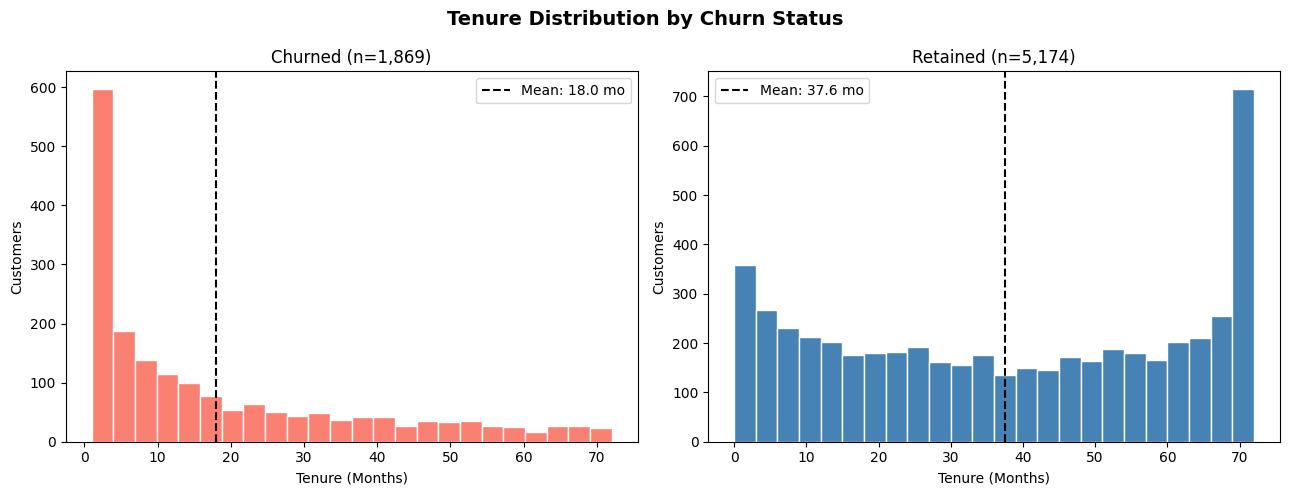

Insight: 55% of churners left within the first 12 months


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Tenure Distribution by Churn Status", fontsize=14, fontweight="bold")

for ax, (label, color, title) in zip(axes, [
    ("Yes", "salmon",    "Churned"),
    ("No",  "steelblue", "Retained")
]):
    subset = df[df["Churn"] == label]["tenure"]
    ax.hist(subset, bins=24, color=color, edgecolor="white")
    ax.axvline(subset.mean(), color="black", linestyle="--",
               label=f"Mean: {subset.mean():.1f} mo")
    ax.set_title(f"{title} (n={len(subset):,})")
    ax.set_xlabel("Tenure (Months)")
    ax.set_ylabel("Customers")
    ax.legend()

plt.tight_layout()
plt.show()

pct_early = (df[df["Churn"] == "Yes"]["tenure"] <= 12).mean()
print(f"Insight: {pct_early:.0%} of churners left within the first 12 months")

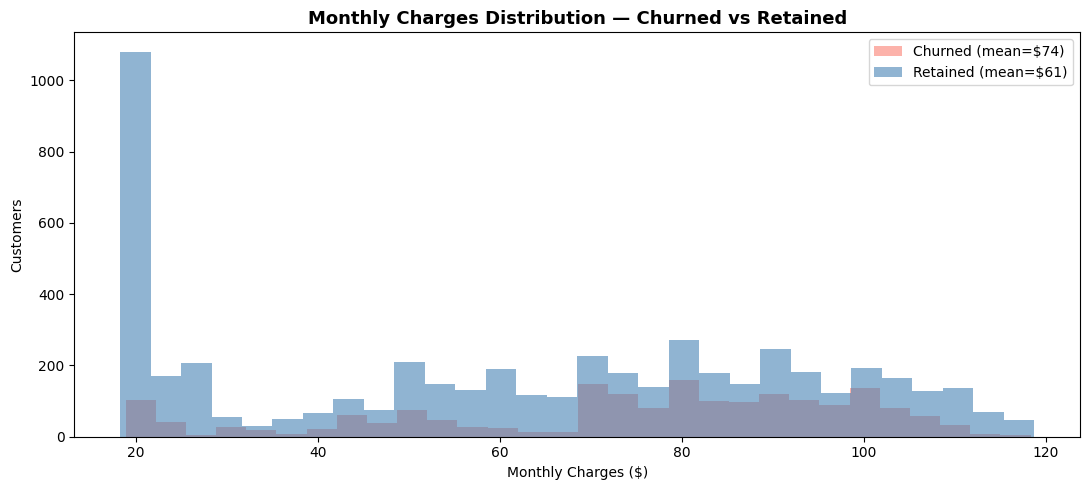

Avg charge — Churned: $74.44  |  Retained: $61.27
Churned customers pay $13.18/mo more on average


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

for label, color, name in [("Yes", "salmon", "Churned"), ("No", "steelblue", "Retained")]:
    subset = df[df["Churn"] == label]["MonthlyCharges"]
    ax.hist(subset, bins=30, color=color, alpha=0.6,
            label=f"{name} (mean=${subset.mean():.0f})")

ax.set_title("Monthly Charges Distribution — Churned vs Retained", fontsize=13, fontweight="bold")
ax.set_xlabel("Monthly Charges ($)")
ax.set_ylabel("Customers")
ax.legend()

plt.tight_layout()
plt.show()

churned_avg  = df[df["Churn"] == "Yes"]["MonthlyCharges"].mean()
retained_avg = df[df["Churn"] == "No"]["MonthlyCharges"].mean()
print(f"Avg charge — Churned: ${churned_avg:.2f}  |  Retained: ${retained_avg:.2f}")
print(f"Churned customers pay ${churned_avg - retained_avg:.2f}/mo more on average")

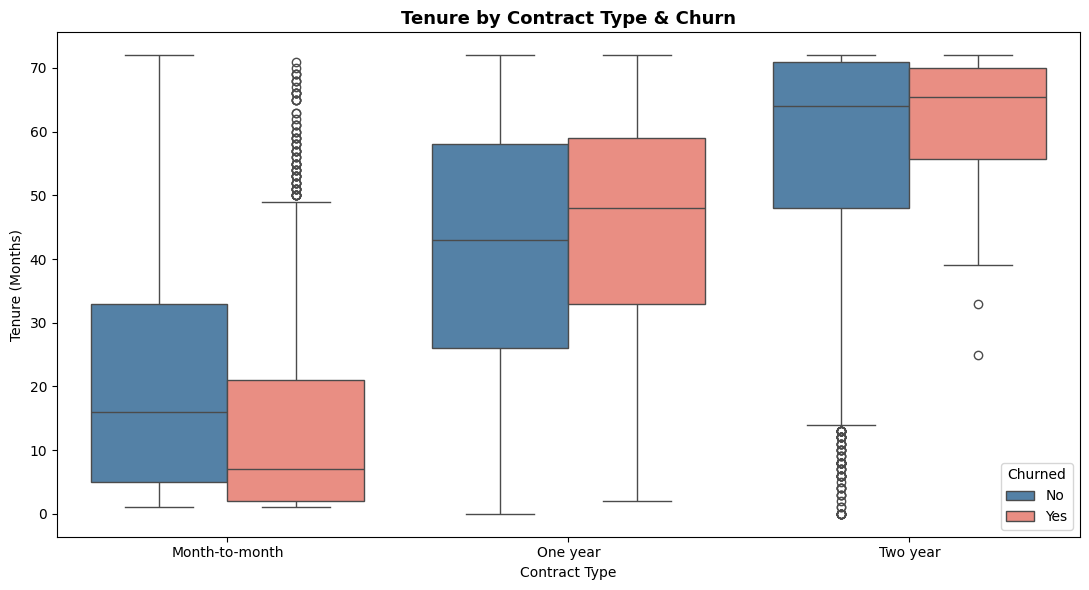

Insight: Month-to-month churners have a much lower median tenure than long-term contract holders


In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="Contract", y="tenure", hue="Churn",
    order=["Month-to-month", "One year", "Two year"],
    palette={"Yes": "salmon", "No": "steelblue"},
    ax=ax
)

ax.set_title("Tenure by Contract Type & Churn", fontsize=13, fontweight="bold")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Tenure (Months)")
ax.legend(title="Churned")

plt.tight_layout()
plt.show()
print("Insight: Month-to-month churners have a much lower median tenure than long-term contract holders")

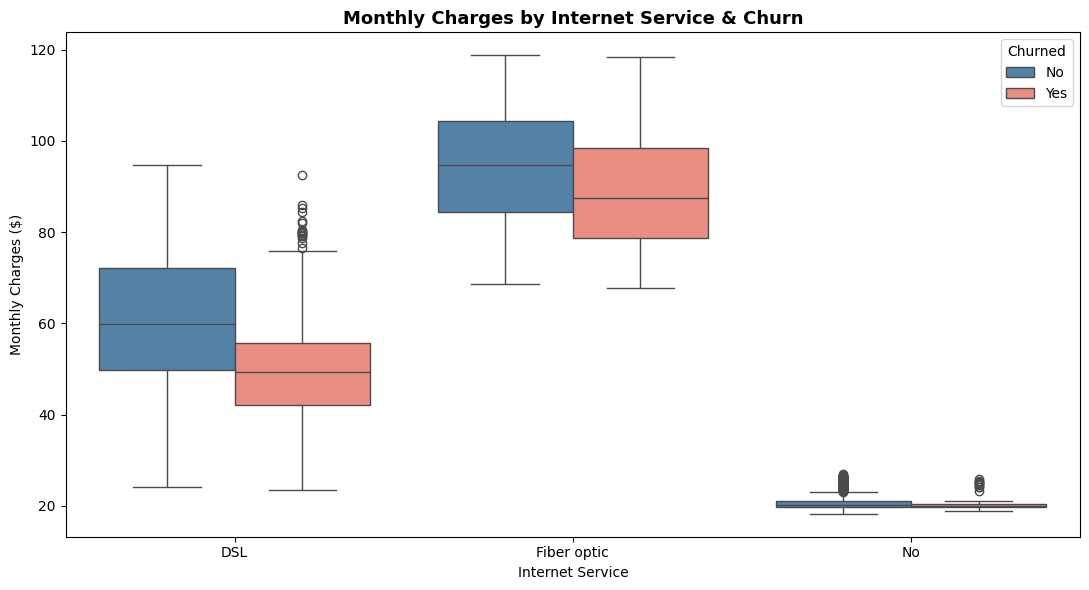

Insight: Fiber optic churners pay the highest charges yet leave at the highest rate


In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="InternetService", y="MonthlyCharges", hue="Churn",
    palette={"Yes": "salmon", "No": "steelblue"},
    ax=ax
)

ax.set_title("Monthly Charges by Internet Service & Churn", fontsize=13, fontweight="bold")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Monthly Charges ($)")
ax.legend(title="Churned")

plt.tight_layout()
plt.show()
print("Insight: Fiber optic churners pay the highest charges yet leave at the highest rate")

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["MonthlyCharges", "TotalCharges"])

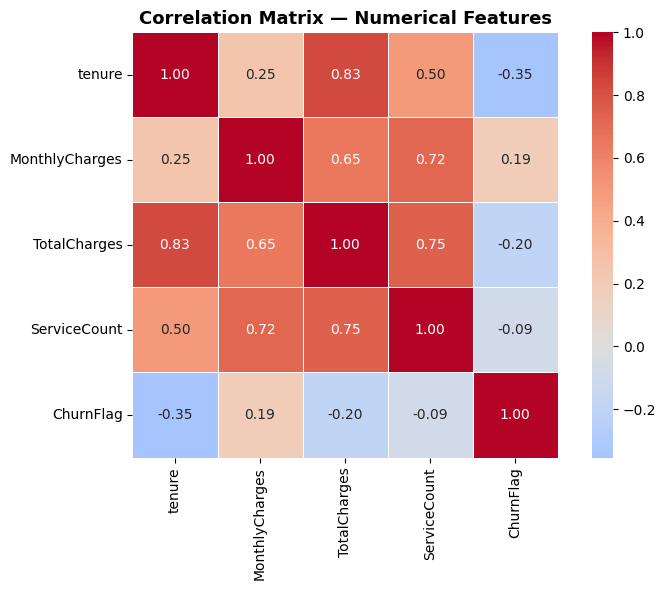

Insight: Tenure has a negative correlation with churn — longer-tenured customers rarely leave


In [10]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount", "ChurnFlag"]
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, square=True,
    linewidths=0.5, ax=ax
)
ax.set_title("Correlation Matrix — Numerical Features", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()
print("Insight: Tenure has a negative correlation with churn — longer-tenured customers rarely leave")

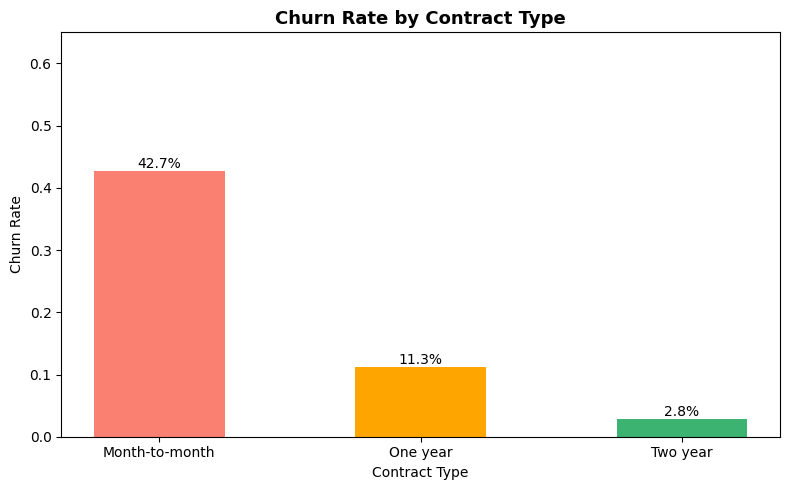

In [11]:
churn_contract = (
    df.groupby("Contract")["ChurnFlag"].mean().reindex(["Month-to-month", "One year", "Two year"]).reset_index().rename(columns={"ChurnFlag": "ChurnRate"})
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(churn_contract["Contract"], churn_contract["ChurnRate"],
              color=["salmon", "orange", "mediumseagreen"], width=0.5)
ax.bar_label(
    bars,
    labels=[f"{rate:.1%}" for rate in churn_contract["ChurnRate"]]
)

ax.set_title("Churn Rate by Contract Type", fontsize=13, fontweight="bold")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Churn Rate")
ax.set_ylim(0, 0.65)

plt.tight_layout()
plt.show()

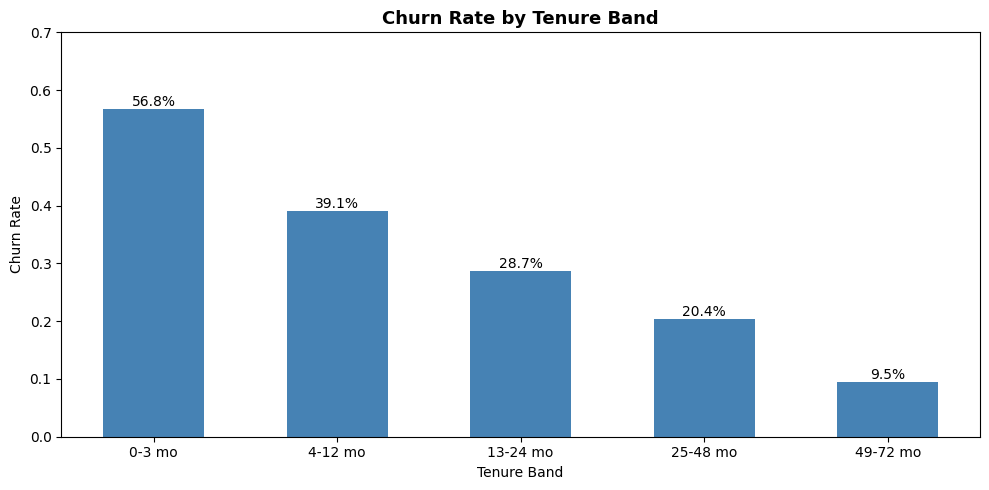

In [12]:
churn_tenure = (
    df.groupby("TenureBand", observed=True)["ChurnFlag"]
    .mean()
    .reset_index()
    .rename(columns={"ChurnFlag": "ChurnRate"})
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(churn_tenure["TenureBand"].astype(str), churn_tenure["ChurnRate"],
              color="steelblue", width=0.55)

ax.bar_label(
    bars,
    labels=[f"{rate:.1%}" for rate in churn_tenure["ChurnRate"]]
)

ax.set_title("Churn Rate by Tenure Band", fontsize=13, fontweight="bold")
ax.set_xlabel("Tenure Band")
ax.set_ylabel("Churn Rate")
ax.set_ylim(0, 0.70)

plt.tight_layout()
plt.show()

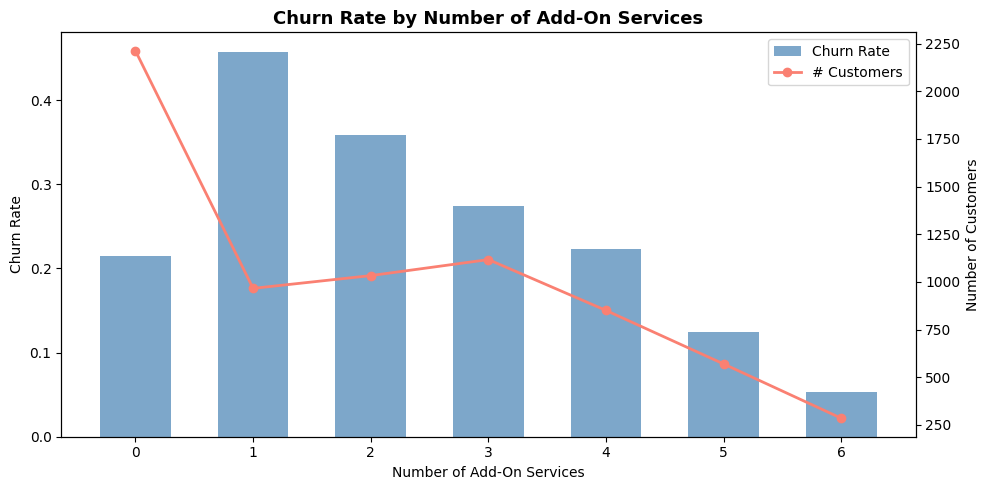

Insight: Customers with 0 add-on services churn at nearly 2x the rate of those with 4+ services


In [13]:
svc_churn = (
    df.groupby("ServiceCount")["ChurnFlag"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "ChurnRate", "count": "Customers"})
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(svc_churn["ServiceCount"], svc_churn["ChurnRate"],
        color="steelblue", alpha=0.7, width=0.6, label="Churn Rate")
ax2.plot(svc_churn["ServiceCount"], svc_churn["Customers"],
         color="salmon", marker="o", linewidth=2, label="# Customers")

ax1.set_title("Churn Rate by Number of Add-On Services", fontsize=13, fontweight="bold")
ax1.set_xlabel("Number of Add-On Services")
ax1.set_ylabel("Churn Rate")
ax2.set_ylabel("Number of Customers")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()
print("Insight: Customers with 0 add-on services churn at nearly 2x the rate of those with 4+ services")

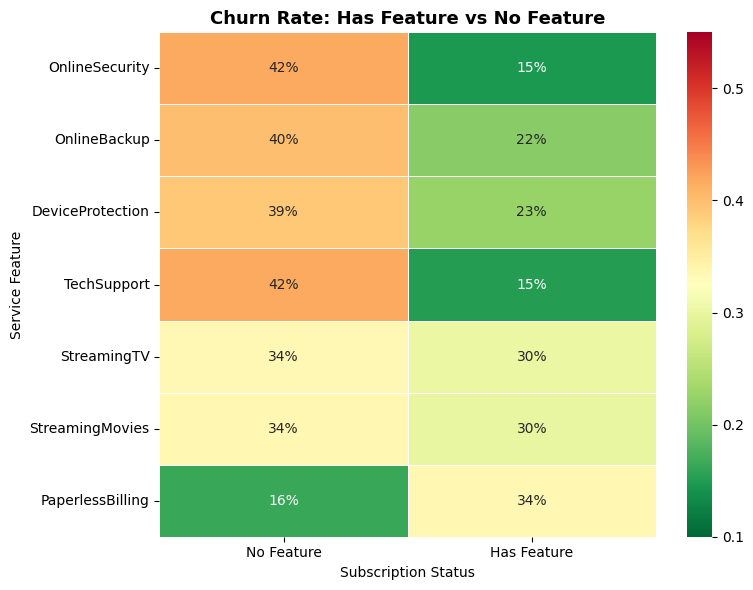

Insight: OnlineSecurity and TechSupport subscribers churn far less than those without


In [14]:
features = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling"]

rates = {}
for f in features:
    sub = df[df[f].isin(["Yes", "No"])]
    rates[f] = sub.groupby(f)["ChurnFlag"].mean()

rate_df = pd.DataFrame(rates).T.rename(columns={"Yes": "Has Feature", "No": "No Feature"})

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(rate_df, annot=True, fmt=".0%", cmap="RdYlGn_r",
            linewidths=0.5, vmin=0.1, vmax=0.55, ax=ax)
ax.set_title("Churn Rate: Has Feature vs No Feature", fontsize=13, fontweight="bold")
ax.set_xlabel("Subscription Status")
ax.set_ylabel("Service Feature")

plt.tight_layout()
plt.show()
print("Insight: OnlineSecurity and TechSupport subscribers churn far less than those without")

# Key Findings

Overview:
The dataset covers 7,043 IBM Telco customers with 21 features. The overall churn rate is approximately 26.5% i.e. roughly 1 in 4 customers leaves.

1. **New customers are the highest flight risk**

About half of all churners left within the first 12 months. The tenure distribution for churned customers is heavily skewed toward the early months.

2. **Month-to-month contracts drive the bulk of churn**

Churn rate by contract type is huge: month-to-month customers churn at roughly 43%, one-year contracts around 11%, and two-year contracts at just 3%.

3. **Churned customers actually pay more**

Churned customers pay noticeably higher monthly charges on average than retained ones (~74 vs ~61/month). Fiber optic internet users pay the highest charges and simultaneously have the highest churn rate.

4. **Tenure is the single strongest negative predictor of churn**

The correlation matrix confirms that the longer a customer has been with the company, the less likely they are to churn.


5. **Security and support features are especially protective**

OnlineSecurity and TechSupport subscribers have dramatically lower churn rates than non-subscribers.

7. **Senior citizens churn rate is higher**
